In [5]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('injury+stat.csv')

# Lọc các dòng có chấn thương
injury_data = df.dropna(subset=['INJURED_TYPE', 'DAYS MISSED'])

# 1. Thống kê mô tả từng loại
summary = injury_data.groupby('INJURED_TYPE')['DAYS MISSED'].agg(['count', 'mean', 'std', 'median'])
print(summary.sort_values(by='count', ascending=False).head(10))

# 2. Kiểm định T-test giữa Ankle và Knee
ankle_days = injury_data[injury_data['INJURED_TYPE'] == 'Sprained_ankle']['DAYS MISSED']
knee_days = injury_data[injury_data['INJURED_TYPE'] == 'Sore_knee']['DAYS MISSED']

t_stat, p_val = stats.ttest_ind(ankle_days, knee_days)
print(f"P-value so sánh Ankle và Knee: {p_val}")

                 count       mean        std  median
INJURED_TYPE                                        
Sprained_ankle     588  10.248299  17.782126     5.0
Sore_knee          353   6.458924  13.832773     3.0
Sore_ankle          95   4.873684   4.916845     3.0
Sore_lower_back     92   5.891304   8.093487     3.5
Knee_injury         86  15.279070  40.088036     2.5
P-value so sánh Ankle và Knee: 0.0006324536655443326


/tmp/ipykernel_23926/3128913804.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_injuries.values, y=top_injuries.index, ax=ax1, palette='viridis')


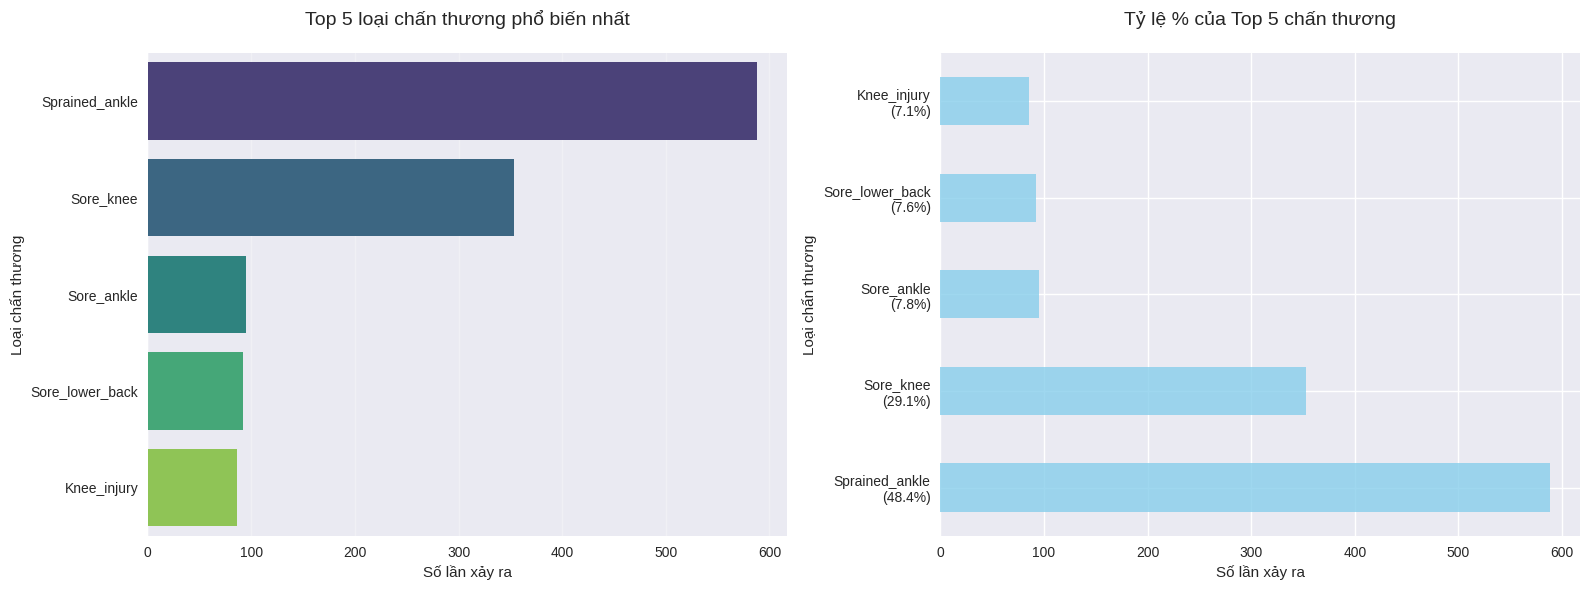

In [8]:
# 1. SEABORN + MATPLOTLIB (nhanh, đẹp)
plt.style.use('seaborn-v0_8')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Barplot TOP 15
top_injuries = injury_data['INJURED_TYPE'].value_counts().head(15)
sns.barplot(x=top_injuries.values, y=top_injuries.index, ax=ax1, palette='viridis')
ax1.set_title('Top 5 loại chấn thương phổ biến nhất', fontsize=14, pad=20)
ax1.set_xlabel('Số lần xảy ra')
ax1.set_ylabel('Loại chấn thương')
ax1.grid(axis='x', alpha=0.3)

# Horizontal bar + % 
total = len(injury_data)
percent = (top_injuries / total * 100).round(1)
ax2 = top_injuries.plot(kind='barh', ax=ax2, color='skyblue', alpha=0.8)
ax2.set_title('Tỷ lệ % của Top 5 chấn thương', fontsize=14, pad=20)
ax2.set_xlabel('Số lần xảy ra')
ax2.set_ylabel('Loại chấn thương')
ax2.set_yticklabels([f"{label}\n({pct}%)" for label, pct in zip(top_injuries.index, percent)])

plt.tight_layout()
plt.show()

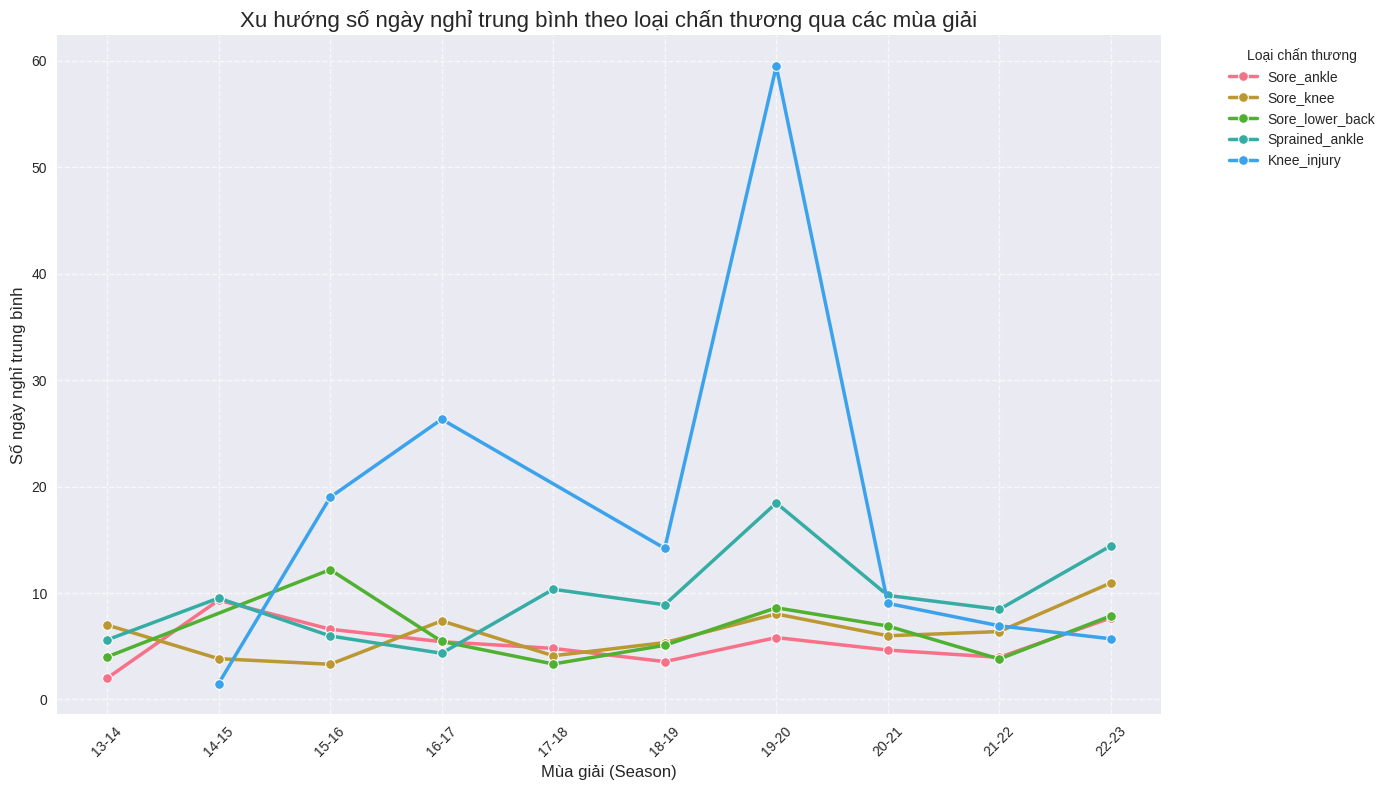

In [15]:
# 2. Làm sạch dữ liệu: Loại bỏ các dòng thiếu thông tin quan trọng
df_clean = df.dropna(subset=['INJURED_TYPE', 'DAYS MISSED', 'SEASON'])

# 3. Lấy danh sách 5 loại chấn thương xuất hiện nhiều nhất
top_5_types = df_clean['INJURED_TYPE'].value_counts().nlargest(5).index.tolist()

# 4. Lọc dữ liệu chỉ lấy 5 loại này
df_top5 = df_clean[df_clean['INJURED_TYPE'].isin(top_5_types)]

# 5. Tính số ngày nghỉ trung bình (mean) theo từng mùa giải và từng loại chấn thương
seasonal_avg = df_top5.groupby(['SEASON', 'INJURED_TYPE'])['DAYS MISSED'].mean().reset_index()

# 6. Sắp xếp mùa giải theo thứ tự thời gian (13-14 -> 22-23)
seasonal_avg = seasonal_avg.sort_values('SEASON')

# 7. Vẽ biểu đồ
plt.figure(figsize=(14, 8))
sns.lineplot(data=seasonal_avg, x='SEASON', y='DAYS MISSED', hue='INJURED_TYPE', marker='o', linewidth=2.5)

# Tinh chỉnh biểu đồ
plt.title('Xu hướng số ngày nghỉ trung bình theo loại chấn thương qua các mùa giải', fontsize=16)
plt.xlabel('Mùa giải (Season)', fontsize=12)
plt.ylabel('Số ngày nghỉ trung bình', fontsize=12)
plt.legend(title='Loại chấn thương', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Xoay nhãn trục X để dễ đọc
plt.tight_layout()